# Practical 12: **MobileNet** - Lightweight CNNs with **Depthwise‑Separable Convolutions**


> In this practical, you will fine‑tune **MobileNet** on the **same flowers dataset** as Practicals 7–11, using the **same pipeline** (data splits, loaders, training loop, evaluation, predictions). You’ll also **inspect MobileNet’s structure** and parameter counts to understand how it achieves **high accuracy with far fewer parameters**.


## Learning Goals
By the end of this notebook, you will be able to:
- Explain how **depthwise‑separable convolutions** reduce parameters and FLOPs compared to standard convolutions.
- Describe the **MobileNet (v1/v2) design**: depthwise + pointwise (1×1) convolutions, **width multiplier** (α) and **resolution multiplier** (ρ), and **inverted residuals with linear bottlenecks** (v2).
- Compare MobileNet to **AlexNet, VGG, GoogLeNet, SqueezeNet,** and **ResNet** in terms of **design philosophy, parameters, and efficiency**.
- Fine‑tune a pretrained **MobileNet** on the **flowers dataset** using the **same code structure** as Practicals 7–11.
- Inspect and report **parameter counts per layer type**, highlighting the impact of depthwise vs pointwise convolutions.


## Dataset
- Download the **flowers dataset** from my Google Drive: [Flowers Dataset Link](https://drive.google.com/file/d/1Oaghg3cBXOD88LAfa5pWXzuHtiJ93o7O/view?usp=sharing)
- We reuse the **same flowers dataset** and **the same directory structure** as Practicals 7–11:

```
DATA_DIR/
 ├── train/
 ├── val/
 └── test/
```

> **Important:** Set `DATA_DIR` to the **same path** you used previously so that loaders and evaluation behave identically.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# ===== Keep names identical to earlier practicals wherever possible =====
# Adjust DATA_DIR if your path differs; folder structure must be .../train, .../val, .../test

import os, copy, time, math, itertools, json, random
from typing import Tuple, List

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Reproducibility
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ===== Paths and Hyperparameters (keep consistent) =====
# Set this to the SAME folder you used in Practicals 7–11
DATA_DIR = "/content/drive/MyDrive/flowers"  # <-- change if needed

IMG_SIZE   = 224        # used previously
BATCH_SIZE = 16         # same as earlier practicals (adjust if you used a different value)
EPOCHS     = 50         # keep aligned with previous fine‑tuning runs
LR         = 1e-3       # initial learning rate
WEIGHT_DECAY = 1e-4

# Data augmentation & normalization (ImageNet stats) — consistent with prior notebooks
train_tfms = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

eval_tfms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Datasets & Loaders (same variable names as before)
train_ds = datasets.ImageFolder(os.path.join(DATA_DIR, "train"), transform=train_tfms)
val_ds   = datasets.ImageFolder(os.path.join(DATA_DIR, "val"),   transform=eval_tfms)
test_ds  = datasets.ImageFolder(os.path.join(DATA_DIR, "test"),  transform=eval_tfms)

class_names = train_ds.classes
num_classes = len(class_names)
print("Classes:", class_names)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

Using device: cuda
Classes: ['Lilly', 'Lotus', 'Orchid', 'Sunflower', 'Tulip']


## Quick Recap: AlexNet → VGG → GoogLeNet → SqueezeNet → ResNet
- **AlexNet (2012):** Big early convs & pooling; first breakthrough on ImageNet with ReLU & dropout.
- **VGG‑16 (2014):** Deep **stacks of 3×3** convs; simple & powerful but **heavy** (≈138M params).
- **GoogLeNet/Inception v1 (2014):** **Inception modules** mix 1×1, 3×3, 5×5 in parallel for computation‑efficient depth.
- **SqueezeNet (2016):** **Fire modules** (squeeze 1×1 → expand 1×1/3×3) to reach AlexNet‑level accuracy with **50× fewer params**.
- **ResNet (2015):** **Residual connections** stabilize training of very deep nets (50/101/152 layers).

**MobileNet (2017–2018)** targets **mobile/embedded** by replacing standard conv with **depthwise‑separable conv**, cutting parameters & FLOPs dramatically.


## Why **MobileNet**? Key idea: **Depthwise-Separable Convolutions**

**Standard 3×3 convolution** (M input ch., N output ch., kernel size D<sub>k</sub>, output spatial size D<sub>out</sub>):
**Cost**<sub>std</sub> = D<sub>k</sub><sup>2</sup> · M · N · D<sub>out</sub><sup>2</sup>

**Depthwise-separable** splits into:

1) **Depthwise (per-channel) 3×3:**  
D<sub>k</sub><sup>2</sup> · M · D<sub>out</sub><sup>2</sup>

2) **Pointwise (1×1) mixing:**  
M · N · D<sub>out</sub><sup>2</sup>

**Overall:**  
**Cost**<sub>dwsep</sub> = D<sub>k</sub><sup>2</sup> · M · D<sub>out</sub><sup>2</sup> + M · N · D<sub>out</sub><sup>2</sup>

**Relative cost (speed-up):**  
Cost<sub>std</sub> / Cost<sub>dwsep</sub> = (D<sub>k</sub><sup>2</sup> · M · N · D<sub>out</sub><sup>2</sup>) / (M · D<sub>out</sub><sup>2</sup> · (D<sub>k</sub><sup>2</sup> + N)) = (D<sub>k</sub><sup>2</sup> · N) / (D<sub>k</sub><sup>2</sup> + N)

For D<sub>k</sub> = 3 → D<sub>k</sub><sup>2</sup> = 9:  9N / (9 + N) ≈ 8–9× when N is moderately large.



**MobileNet v1 (2017):** stacks **DepthwiseConv (3×3, groups = M)** + **PointwiseConv (1×1)** blocks.  
**MobileNet v2 (2018):** adds **Inverted Residuals** and **Linear Bottlenecks**:
- Expand (1×1) → **Depthwise 3×3** → Project (1×1, linear)
- Uses **residual** connections when input/output shapes match
- Improves the accuracy–efficiency trade-off

**Scalability knobs:**
- **Width multiplier (α)** – scales channels (e.g., 0.5, 0.75, 1.0)
- **Resolution multiplier (ρ)** – scales input size (e.g., 192, 160, 128)

**Symbols:** M = input channels, N = output channels, D<sub>k</sub> = kernel size, D<sub>out</sub> = output spatial size.


### Depthwise-Separable Convolutions Block:

<center>
<img src="images/Depthwise-separable-convolutions.jpg" alt="DSC block" width="600" height="400"/>
</center>

# How It Recognizes Flowers

## The Mobile Botanical Expert

**Think of MobileNet as a field botany app that works perfectly even on your smartphone.**

### Step-by-Step Process:

**1. Standard Convolution Start:**
- Initial layer processes full flower image
- **Flower detection**: "Basic botanical image understanding established"

**2. Depthwise Separable Convolutions: The Efficiency Secret**

Each MobileNet block splits the botanical work smartly:

**Depthwise Convolution:**
- **Each color channel processed separately**
- Like having color specialists: "Red-channel expert, Green-channel expert, Blue-channel expert"
- **Flower detection**: 
  - Red expert: "Finds red petal edges in Tulips and some Orchids"
  - Green expert: "Identifies stem and leaf patterns, Lotus water backgrounds"
  - Blue expert: "Detects blue sky backgrounds, water reflections"

**Pointwise Convolution (1×1):**
- **Combines insights from all color channel experts**
- Like a botanical coordinator: "Combine red petals + green stems + blue backgrounds"
- **Flower detection**: "All color evidence points to specific flower features"

**3. Progressive MobileNet Blocks:**
- **Early blocks**: "Efficient basic flower feature detection"
- **Middle blocks**: "Smart combination of color and texture information"
  - Sunflower: "Yellow dominance + circular pattern + green stem"
  - Lotus: "Pink/white petals + green water lily pads + blue water"
- **Late blocks**: "Final integration - definitely a [flower type]!"

**4. Global Average Pooling:**
- Lightweight final processing
- **Output**: "88% confident this is a Sunflower - and I run perfectly on your phone in the field!"

### MobileNet's Character:
- **Mobile-optimized**: Designed specifically for field botany on phones and tablets
- **Fast**: Real-time flower processing capability
- **Practical**: Good flower identification with minimal computational requirements

### How MobileNet Improves on Previous Models:

| Aspect | AlexNet | VGGNet | GoogleNet | SqueezeNet | ResNet | MobileNet |
|--------|---------|---------|-----------|------------|---------|-----------|
| **Field Deployment** | Impossible | Impossible | Challenging | Possible | Challenging | Optimized |
| **Real-time Processing** | No | No | Limited | Limited | Limited | Yes |
| **Computation Type** | Standard conv | Standard conv | Mixed conv | Fire modules | Residual blocks | Depthwise separable |
| **Speed Focus** | No | No | Efficiency | Size | Accuracy | Speed |
| **Flower Recognition** | Slow deep | Slow methodical | Smart efficient | Ultra-compact | Deep memory | Real-time mobile |
| **Field Botany Use** | Lab only | Lab only | Limited field | Possible field | Limited field | Perfect field use |
| **Accuracy** | 85% | 92% | 93% | 85% | 95% | 88% |

**Key Improvement**: MobileNet's depthwise separable convolutions enable real-time flower recognition on mobile devices during field work - perfect for botanical field trips and nature walks where instant flower identification is needed.

### Anatomy of **MobileNetV2** (stages & shapes)
A typical MobileNetV2(α=1.0, 224×224) layout:

| Stage | Operator                              | t (expand) | c (out ch) | n (blocks) | s (stride) |
|:-----:|---------------------------------------|:----------:|:----------:|:----------:|:----------:|
| Stem  | Conv 3×3                              | —          | 32         | 1          | 2          |
| 1     | Bottleneck (DW‑Sep + residual)        | 1          | 16         | 1          | 1          |
| 2     | Bottleneck                             | 6          | 24         | 2          | 2          |
| 3     | Bottleneck                             | 6          | 32         | 3          | 2          |
| 4     | Bottleneck                             | 6          | 64         | 4          | 2          |
| 5     | Bottleneck                             | 6          | 96         | 3          | 1          |
| 6     | Bottleneck                             | 6          | 160        | 3          | 2          |
| 7     | Bottleneck                             | 6          | 320        | 1          | 1          |
| Head  | Conv 1×1 → Global AvgPool → FC        | —          | 1280       | 1          | —          |

- **Bottleneck block (inverted residual):** `1×1 expand (t×)` → `3×3 depthwise (s)` → `1×1 project (linear)` + **residual** if shapes match.
- **Width multiplier (α):** scales all `c` channels; **resolution multiplier (ρ):** downscales input size.


## Inspecting **MobileNet** Structure and Parameters
We’ll fine‑tune **MobileNetV2** (pretrained on ImageNet) and replace the last classifier layer with `num_classes` outputs. Then we’ll **count parameters** per layer type to see how depthwise vs pointwise convs dominate the distribution.


In [3]:
# Build MobileNetV2 (ImageNet pretrained) and adapt classifier
use_pretrained = True
try:
    mobilenet = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1 if use_pretrained else None)
except Exception:
    # Fallback for older torchvision versions
    mobilenet = models.mobilenet_v2(pretrained=use_pretrained)

# Replace classifier to match our flower classes
in_features = mobilenet.classifier[-1].in_features
mobilenet.classifier[-1] = nn.Linear(in_features, num_classes)

mobilenet = mobilenet.to(device)
print(mobilenet)  # architecture overview

# Count parameters overall
total_params = sum(p.numel() for p in mobilenet.parameters())
trainable_params = sum(p.numel() for p in mobilenet.parameters() if p.requires_grad)
print(f"Total params: {total_params:,} | Trainable: {trainable_params:,}")

MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

In [4]:
# Inspect the last few inverted residual blocks (expand -> depthwise -> project)
import torch.nn as nn
from torchvision.models.mobilenetv2 import InvertedResidual  # <- change this line

def describe_inverted_residual(m: InvertedResidual, name="block"):
    # recurse to find Conv2d inside ConvNorm/ConvBN wrappers
    convs = [c for c in m.modules() if isinstance(c, nn.Conv2d)]
    roles = []
    for c in convs:
        if c.kernel_size == (1, 1) and c.in_channels != c.out_channels:
            roles.append(("expand_1x1", c))
        elif c.kernel_size == (3, 3) and c.groups == c.in_channels:
            roles.append(("depthwise_3x3", c))
        elif c.kernel_size == (1, 1) and c.in_channels >= c.out_channels:
            roles.append(("project_1x1", c))
        else:
            roles.append(("other", c))
    print(f"{name}: residual={getattr(m, 'use_res_connect', False)}")
    for role, c in roles:
        print(f"  - {role:14} | in={c.in_channels:4d} out={c.out_channels:4d} stride={tuple(c.stride)} groups={c.groups}")

# indices of V2 inverted residuals
idxs = [i for i, m in enumerate(mobilenet.features) if isinstance(m, InvertedResidual)]
for i in idxs[-3:]:
    describe_inverted_residual(mobilenet.features[i], name=f"features[{i}]")


features[15]: residual=True
  - expand_1x1     | in= 160 out= 960 stride=(1, 1) groups=1
  - depthwise_3x3  | in= 960 out= 960 stride=(1, 1) groups=960
  - expand_1x1     | in= 960 out= 160 stride=(1, 1) groups=1
features[16]: residual=True
  - expand_1x1     | in= 160 out= 960 stride=(1, 1) groups=1
  - depthwise_3x3  | in= 960 out= 960 stride=(1, 1) groups=960
  - expand_1x1     | in= 960 out= 160 stride=(1, 1) groups=1
features[17]: residual=False
  - expand_1x1     | in= 160 out= 960 stride=(1, 1) groups=1
  - depthwise_3x3  | in= 960 out= 960 stride=(1, 1) groups=960
  - expand_1x1     | in= 960 out= 320 stride=(1, 1) groups=1


In [5]:
# Helper to classify conv layers
def conv_role(mod: nn.Module):
    if isinstance(mod, nn.Conv2d):
        k = mod.kernel_size
        if k == (1,1):
            return "pointwise_1x1"
        # Depthwise: groups == in_channels and out_channels == in_channels
        if mod.groups == mod.in_channels and mod.out_channels == mod.in_channels:
            return "depthwise_3x3" if k == (3,3) else "depthwise_other"
        return "standard_conv"
    return None

from collections import defaultdict
bucket_params = defaultdict(int)

for m in mobilenet.modules():
    role = conv_role(m)
    if role:
        bucket_params[role] += sum(p.numel() for p in m.parameters())

bucket_params = dict(bucket_params)
bucket_params["others"] = total_params - sum(bucket_params.values())
for k,v in bucket_params.items():
    print(f"{k:>16}: {v:,} params")

   standard_conv: 864 params
   depthwise_3x3: 64,224 params
   pointwise_1x1: 2,124,672 params
          others: 40,517 params


In [6]:
# Build a small parameter table (layer name, role, params)
def layer_param_table(model):
    rows = []
    for name, m in model.named_modules():
        if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
            role = conv_role(m) if isinstance(m, nn.Conv2d) else "linear"
            params = sum(p.numel() for p in m.parameters())
            rows.append((name, role, params))
    rows.sort(key=lambda x: x[2], reverse=True)
    # print top 15
    print(f"{'layer':50} {'role':18} {'params':>12}")
    print("-"*84)
    for name, role, params in rows[:15]:
        print(f"{name:50} {role:18} {params:12,d}")
    return rows

_ = layer_param_table(mobilenet)

layer                                              role                     params
------------------------------------------------------------------------------------
features.18.0                                      pointwise_1x1           409,600
features.17.conv.2                                 pointwise_1x1           307,200
features.15.conv.0.0                               pointwise_1x1           153,600
features.15.conv.2                                 pointwise_1x1           153,600
features.16.conv.0.0                               pointwise_1x1           153,600
features.16.conv.2                                 pointwise_1x1           153,600
features.17.conv.0.0                               pointwise_1x1           153,600
features.14.conv.2                                 pointwise_1x1            92,160
features.12.conv.0.0                               pointwise_1x1            55,296
features.12.conv.2                                 pointwise_1x1            55,296
fe

### Fine‑Tuning Policy
1) **Stage 1 (head‑only):** Freeze the backbone; train only the final classifier.  
2) **Stage 2 (light unfreeze):** Unfreeze the last few inverted‑residual blocks; train with a **lower LR**.

> This mirrors the approach we used for VGG/ResNet transfer learning while respecting MobileNet’s lightweight design.


In [7]:
# Stage 1: freeze backbone
for p in mobilenet.features.parameters():
    p.requires_grad = False

# Loss & optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, mobilenet.parameters()), lr=LR, weight_decay=WEIGHT_DECAY)

In [8]:
def accuracy(output, target):
    with torch.no_grad():
        preds = output.argmax(dim=1)
        return (preds == target).float().mean().item()

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    run_loss, run_acc, n = 0.0, 0.0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        out = model(images)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        run_loss += loss.item() * images.size(0)
        run_acc  += (out.argmax(1) == labels).float().sum().item()
        n += images.size(0)
    return run_loss/n, run_acc/n

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    run_loss, run_acc, n = 0.0, 0.0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        out = model(images)
        loss = criterion(out, labels)
        run_loss += loss.item() * images.size(0)
        run_acc  += (out.argmax(1) == labels).float().sum().item()
        n += images.size(0)
    return run_loss/n, run_acc/n

def train_model(model, train_loader, val_loader, epochs=EPOCHS, lr=LR):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_wts, best_val = copy.deepcopy(model.state_dict()), -1.0
    for epoch in range(1, epochs+1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        va_loss, va_acc = evaluate(model, val_loader, criterion, device)
        history["train_loss"].append(tr_loss); history["val_loss"].append(va_loss)
        history["train_acc"].append(tr_acc);   history["val_acc"].append(va_acc)
        if va_acc > best_val:
            best_val = va_acc
            best_wts = copy.deepcopy(model.state_dict())
        dt = time.time() - t0
        print(f"Epoch {epoch:02d}/{epochs} | "
              f"train loss {tr_loss:.4f} acc {tr_acc:.3f} | "
              f"val loss {va_loss:.4f} acc {va_acc:.3f} | "
              f"{dt:.1f}s")
    model.load_state_dict(best_wts)
    return model, history

# Train Stage 1
model, history1 = train_model(mobilenet, train_loader, val_loader, epochs=EPOCHS)

Epoch 01/50 | train loss 0.7379 acc 0.734 | val loss 0.3996 acc 0.870 | 51.6s
Epoch 02/50 | train loss 0.4862 acc 0.832 | val loss 0.3602 acc 0.880 | 52.3s
Epoch 03/50 | train loss 0.4477 acc 0.847 | val loss 0.3132 acc 0.890 | 50.0s
Epoch 04/50 | train loss 0.4228 acc 0.851 | val loss 0.3167 acc 0.882 | 51.3s
Epoch 05/50 | train loss 0.4023 acc 0.861 | val loss 0.3292 acc 0.884 | 51.3s
Epoch 06/50 | train loss 0.3942 acc 0.856 | val loss 0.2831 acc 0.904 | 56.3s
Epoch 07/50 | train loss 0.4067 acc 0.859 | val loss 0.2983 acc 0.888 | 52.1s
Epoch 08/50 | train loss 0.3697 acc 0.866 | val loss 0.2889 acc 0.894 | 50.1s
Epoch 09/50 | train loss 0.4006 acc 0.860 | val loss 0.2696 acc 0.912 | 51.1s
Epoch 10/50 | train loss 0.3772 acc 0.861 | val loss 0.2701 acc 0.904 | 51.6s
Epoch 11/50 | train loss 0.3676 acc 0.872 | val loss 0.2844 acc 0.898 | 51.3s
Epoch 12/50 | train loss 0.3921 acc 0.854 | val loss 0.3097 acc 0.898 | 50.4s
Epoch 13/50 | train loss 0.3844 acc 0.862 | val loss 0.2867 acc 

In [9]:
# Stage 2: unfreeze the last few inverted residual blocks & train with lower LR
# Identify last N blocks
N_UNFREEZE = 2
blocks = [m for m in mobilenet.features if hasattr(m, 'conv') or isinstance(m, nn.Sequential)]
for b in blocks[-N_UNFREEZE:]:
    for p in b.parameters():
        p.requires_grad = True

# New optimizer with lower LR
optimizer = optim.Adam(filter(lambda p: p.requires_grad, mobilenet.parameters()), lr=LR*0.1, weight_decay=WEIGHT_DECAY)

# Continue training
model, history2 = train_model(mobilenet, train_loader, val_loader, epochs=EPOCHS)

Epoch 01/50 | train loss 0.3894 acc 0.869 | val loss 0.2554 acc 0.908 | 51.5s
Epoch 02/50 | train loss 0.2908 acc 0.897 | val loss 0.2517 acc 0.904 | 52.0s
Epoch 03/50 | train loss 0.2351 acc 0.915 | val loss 0.2283 acc 0.914 | 50.3s
Epoch 04/50 | train loss 0.1985 acc 0.931 | val loss 0.2157 acc 0.934 | 51.7s
Epoch 05/50 | train loss 0.1681 acc 0.935 | val loss 0.1974 acc 0.940 | 51.5s
Epoch 06/50 | train loss 0.1598 acc 0.943 | val loss 0.2154 acc 0.940 | 52.2s
Epoch 07/50 | train loss 0.1333 acc 0.954 | val loss 0.2257 acc 0.932 | 51.9s
Epoch 08/50 | train loss 0.1238 acc 0.956 | val loss 0.1963 acc 0.938 | 51.5s
Epoch 09/50 | train loss 0.1194 acc 0.959 | val loss 0.2305 acc 0.934 | 52.0s
Epoch 10/50 | train loss 0.1112 acc 0.963 | val loss 0.2024 acc 0.938 | 52.1s
Epoch 11/50 | train loss 0.1072 acc 0.962 | val loss 0.2055 acc 0.928 | 52.2s
Epoch 12/50 | train loss 0.0846 acc 0.969 | val loss 0.1864 acc 0.948 | 50.7s
Epoch 13/50 | train loss 0.0823 acc 0.972 | val loss 0.2229 acc 

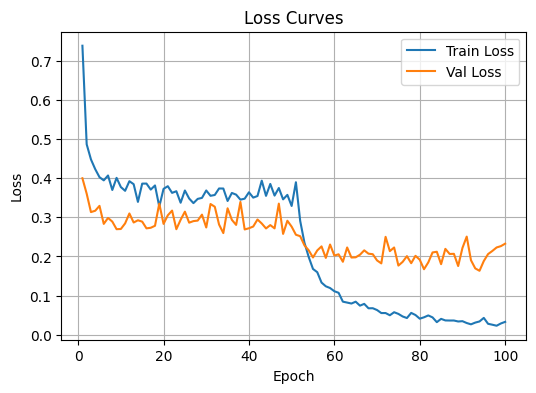

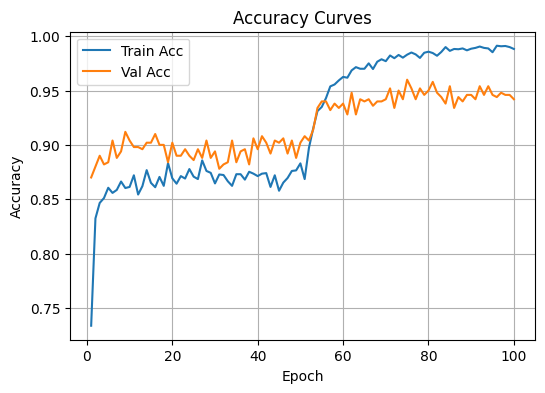

In [10]:
# Plot the learning curves (same style)
def plot_curves(h1, h2=None):
    def merge(hx, hy):
        return [*hx, *hy] if hy else hx
    tr_loss = merge(h1["train_loss"], h2["train_loss"] if h2 else [])
    va_loss = merge(h1["val_loss"],   h2["val_loss"]   if h2 else [])
    tr_acc  = merge(h1["train_acc"],  h2["train_acc"]  if h2 else [])
    va_acc  = merge(h1["val_acc"],    h2["val_acc"]    if h2 else [])

    epochs = range(1, len(tr_loss)+1)

    plt.figure(figsize=(6,4))
    plt.plot(epochs, tr_loss, label="Train Loss")
    plt.plot(epochs, va_loss, label="Val Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Loss Curves"); plt.legend(); plt.grid(True)
    plt.show()

    plt.figure(figsize=(6,4))
    plt.plot(epochs, tr_acc, label="Train Acc")
    plt.plot(epochs, va_acc, label="Val Acc")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.title("Accuracy Curves"); plt.legend(); plt.grid(True)
    plt.show()

plot_curves(history1, history2)

## Final Test Evaluation
We report **test accuracy**, a **confusion matrix**, and a **classification report**.


Test Loss: 0.2471 | Test Acc: 0.928


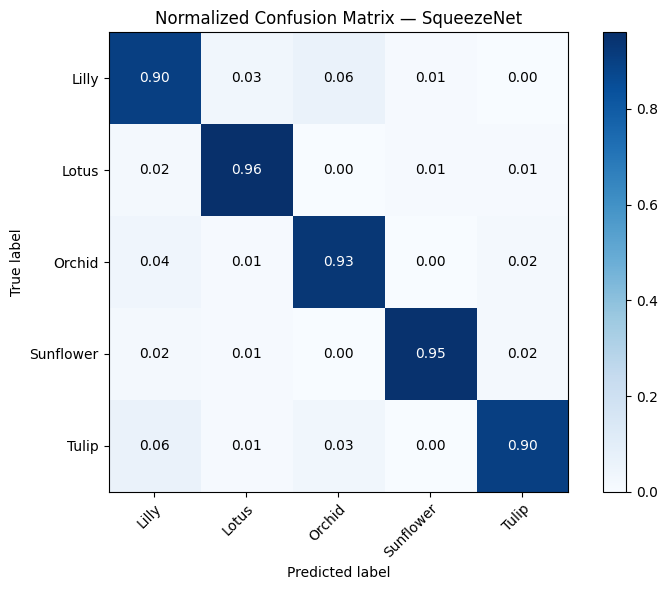

Classification Report:

              precision    recall  f1-score   support

       Lilly       0.87      0.90      0.88       100
       Lotus       0.94      0.96      0.95       100
      Orchid       0.91      0.93      0.92       100
   Sunflower       0.98      0.95      0.96       100
       Tulip       0.95      0.90      0.92       100

    accuracy                           0.93       500
   macro avg       0.93      0.93      0.93       500
weighted avg       0.93      0.93      0.93       500



In [15]:
@torch.no_grad()
def predict_all(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    for images, labels in loader:
        images = images.to(device)
        out = model(images)
        preds = out.argmax(1).cpu().numpy().tolist()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy().tolist())
    return np.array(all_preds), np.array(all_labels)

test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.3f}")

y_pred, y_true = predict_all(model, test_loader)

# Confusion matrix (normalized)
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm_norm, interpolation='nearest', cmap='Blues')
ax.figure.colorbar(im, ax=ax)
ax.set(xticks=np.arange(len(class_names)),
       yticks=np.arange(len(class_names)),
       xticklabels=class_names, yticklabels=class_names,
       ylabel='True label', xlabel='Predicted label',
       title='Normalized Confusion Matrix — SqueezeNet')
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')
# write values
thresh = cm_norm.max() / 2.
for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        ax.text(j, i, f"{cm_norm[i, j]:.2f}",
                ha="center", va="center",
                color="white" if cm_norm[i, j] > thresh else "black")
plt.tight_layout()
plt.show()

print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

## Visualize Predictions
Display a few **test images** with predicted labels (and softmax probabilities).


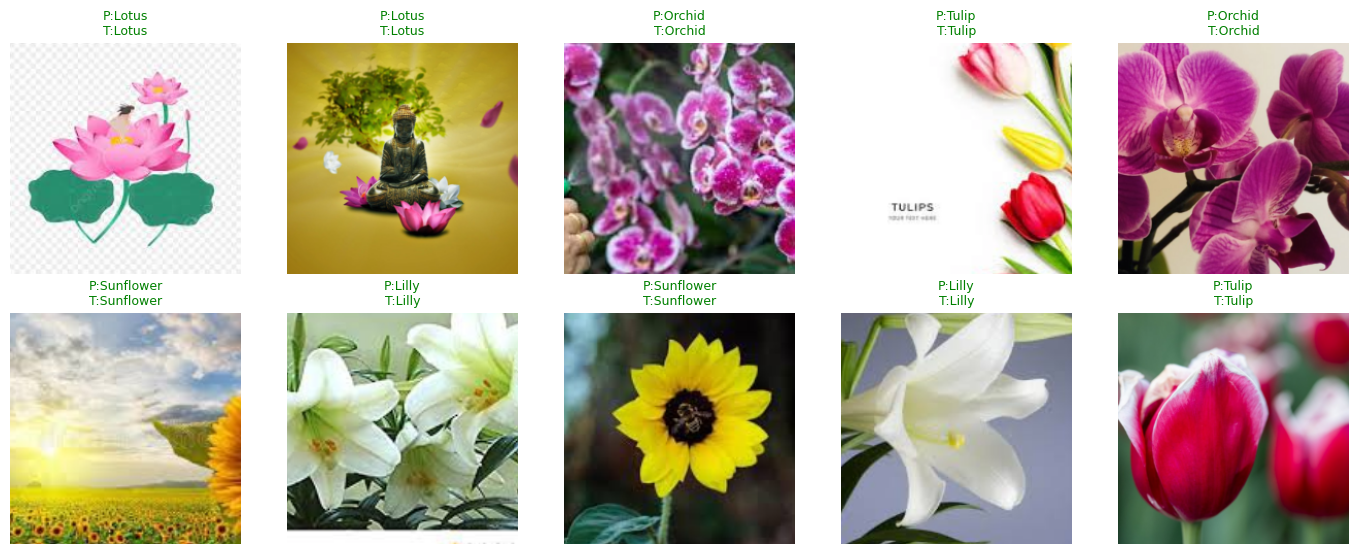

In [16]:
import matplotlib.pyplot as plt
# ---- Visualize a few predictions ----
import math, random
def denormalize(img_tensor, mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)):
    if isinstance(mean, tuple): mean = torch.tensor(mean, device=img_tensor.device).view(3,1,1)
    if isinstance(std, tuple):  std  = torch.tensor(std,  device=img_tensor.device).view(3,1,1)
    return (img_tensor * std + mean).clamp(0,1)

@torch.no_grad()
def show_predictions_balanced(model, dataset, class_names, k_per_class=2, max_total=12):
    model.eval()
    targets = dataset.targets if hasattr(dataset, "targets") else [y for _, y in dataset]
    per_class = {c: [] for c in range(len(class_names))}
    for idx, y in enumerate(targets):
        per_class[int(y)].append(idx)

    chosen = []
    for c in range(len(class_names)):
        pool = per_class[c]
        if pool:
            k = min(k_per_class, len(pool))
            chosen += random.sample(pool, k)
    random.shuffle(chosen)
    chosen = chosen[:max_total]

    imgs, labels = [], []
    for i in chosen:
        img, y = dataset[i]
        imgs.append(img); labels.append(y)
    if not imgs:
        print("No images sampled. Check dataset path.");
    else:
        batch = torch.stack(imgs).to(device)
        labels = torch.tensor(labels, device=device)
        preds = model(batch).argmax(1)

        n = len(imgs); cols = min(5, n); rows = math.ceil(n/cols)
        plt.figure(figsize=(2.8*cols, 2.8*rows))
        for i in range(n):
            plt.subplot(rows, cols, i+1)
            disp = denormalize(batch[i].cpu()).permute(1,2,0)
            p, t = class_names[preds[i].item()], class_names[labels[i].item()]
            plt.imshow(disp); plt.axis("off")
            plt.title(f"P:{p}\nT:{t}", fontsize=9, color=("green" if p==t else "red"))
        plt.tight_layout(); plt.show()

show_predictions_balanced(model, test_ds, class_names, k_per_class=2, max_total=20)

## MobileNet vs. VGG, AlexNet, GoogLeNet, SqueezeNet, ResNet (at a glance)
- **Parameters:** MobileNet (α=1.0) has **far fewer** params than VGG‑16 and ResNet‑50; comparable to or smaller than SqueezeNet but usually with **higher accuracy** on mobile settings.
- **Core block:** Depthwise‑separable conv (v1) / Inverted residual + linear bottleneck (v2) vs. VGG’s 3×3 stacks, GoogLeNet’s Inception, SqueezeNet’s Fire, ResNet’s residual bottlenecks.
- **Speed/Memory:** Designed for **on‑device** inference; **width/resolution multipliers** give fine control over latency–accuracy trade‑offs.
- **Training:** Similar transfer‑learning recipe as VGG/ResNet; unfreezing the last few blocks often suffices.


## Summary
- MobileNet uses **depthwise‑separable convolutions** to reduce parameters and FLOPs dramatically while retaining strong accuracy.
- **MobileNet v2** adds **inverted residuals** and **linear bottlenecks** that further improve accuracy–efficiency.
- We fine‑tuned MobileNet on the **same flowers dataset** with the **same training/evaluation pipeline** as Practicals 7–11.
- We inspected the **parameter distribution** to see the role of **pointwise (1×1)** vs **depthwise (3×3)** convs.

### Next: **DenseNet**
In the next practical, we’ll study **DenseNet**, where layers **concatenate** (not sum) features to encourage **feature reuse** and efficient gradients.


---
📝 This practical was designed by **Dr. Zaid Al-Huda** to give you hands-on experience with **MobileNet**, a clear comparison to **AlexNet, VGG-16, GoogLeNet, SqueezeNet, and ResNet**, and practical skills in **fine-tuning pretrained models** for image classification.